# Week 4: Network Models & Hubs — Assignment

**Learning objectives** — In this assignment you will:

- Implement preferential attachment from scratch and verify it produces hubs
- Compare degree distributions of real and synthetic networks quantitatively
- Detect hubs and measure how well models fit real data (KS statistic)
- Compute CCDFs and estimate power-law exponents with MLE
- Simulate random and targeted node removal to demonstrate the robustness paradox
- Reason about the ultra-small property, the scale-free debate, and Molloy-Reed criterion

## Grading Rubric

| Section | Function | Points |
|---------|----------|--------|
| 1 | `preferential_attachment(n, m, seed)` | 25 |
| 2 | `compare_degree_dists(G_real, G_model, title)` | 10 |
| 3 | `find_hubs(G, threshold_factor)` | 10 |
| 4 | `ks_degree_fit(G_real, G_model)` | 10 |
| 5 | `compute_ccdf` + `estimate_alpha` | 10 |
| 6 | `random_removal` + `targeted_removal` | 20 |
| — | Written questions | 15 |
| | **Total** | **100** |

## Before You Start

**Prerequisites** — you should be comfortable with:

- The Barabási-Albert model: growth + preferential attachment
- Log-log degree plots and what a "straight line" means (power law)
- CCDF plots and MLE power-law fitting
- The ultra-small property: why scale-free networks have shorter paths
- The Molloy-Reed criterion: ⟨k²⟩/⟨k⟩ > 2 for the giant component
- The robustness paradox: robust to random failure, fragile to targeted attack
- The scale-free debate: not every fat-tailed distribution is a power law

**Implementation constraints** — do NOT call these functions:

| Section | Banned functions |
|---------|-----------------|
| 1 | `nx.barabasi_albert_graph`, `models.barabasi_albert` |
| 2 | (none — you may use matplotlib freely) |
| 3 | (none — but implement the logic yourself, no `nx` shortcut) |
| 4 | (none — you may use `scipy.stats.ks_2samp`) |
| 5 | `netsci.utils.fit_power_law` |
| 6 | (none — but you must copy the graph before modifying it) |

**Allowed helpers**: `G.degree()`, `G.nodes()`, `G.edges()`, `G.add_node()`, `G.add_edge()`, `nx.Graph()`, `nx.complete_graph()`, `nx.connected_components()`, `np.random.default_rng()`, `scipy.stats.ks_2samp`

**Reuse your own code**: Section 4 uses your `preferential_attachment` from Section 1. Section 6 tests reference the robustness paradox directly.

In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from netsci.loaders import load_graph
from netsci.utils import SEED
from netsci import models

In [2]:
G_fb = load_graph("facebook")
G_air = load_graph("airports")

facebook: 334 nodes, 2852 edges (undirected)
airports: 500 nodes, 2980 edges (undirected)


**Datasets**:

- **Facebook** (334 nodes, 2,852 edges) — a dense social ego-network with fat-tailed degree distribution and one extreme outlier (k=333). Used in Sections 2-4 to test your model against real data.
- **US Airports** (500 nodes, 2,980 edges) — a hub-and-spoke network where a few major airports connect to 100+ cities. Used in Section 6 for robustness experiments.

---
## Section 1: Preferential Attachment from Scratch (25 pts)

Implement the Barabasi-Albert algorithm **manually** (do not call `nx.barabasi_albert_graph`):

1. Start with a small **complete graph** of `m + 1` nodes
2. For each new node (from `m + 1` to `n - 1`):
   - Connect it to `m` existing nodes, chosen with probability **proportional to their current degree**
   - Use `rng.choice(nodes, size=m, replace=False, p=probabilities)` for the selection
3. Return the final graph

Use the provided `seed` parameter to create `rng = np.random.default_rng(seed)`.

In [3]:
def preferential_attachment(n, m, seed=SEED):
    """Build a BA graph from scratch using preferential attachment.

    Parameters
    ----------
    n : int — total number of nodes
    m : int — edges per new node
    seed : int — random seed

    Returns
    -------
    nx.Graph
    """
    if m < 1:
        raise ValueError("m must be >= 1")
    if n < m + 1:
        raise ValueError("n must be at least m + 1")

    rng = np.random.default_rng(seed)

    # Start from a complete graph on m+1 nodes.
    G = nx.complete_graph(m + 1)

    # Add new nodes one by one, attaching to m existing nodes with
    # probability proportional to current degree.
    for new_node in range(m + 1, n):
        G.add_node(new_node)

        existing_nodes = np.array(list(range(new_node)))
        degrees = np.array([G.degree(node) for node in existing_nodes], dtype=float)
        probabilities = degrees / degrees.sum()

        targets = rng.choice(existing_nodes, size=m, replace=False, p=probabilities)
        for target in targets:
            G.add_edge(new_node, int(target))

    return G

In [5]:
# --- Validation ---
_g = preferential_attachment(500, 3, seed=SEED)
assert isinstance(_g, nx.Graph)
assert _g.number_of_nodes() == 500
# Should have m*(n-m-1) + m*(m-1)/2 edges approximately
_expected_edges = 3 * (500 - 4) + 6  # m*(n-m-1) + C(m+1,2)
assert abs(_g.number_of_edges() - _expected_edges) < 5, (
    f"Expected {_expected_edges} edges, got {_g.number_of_edges()}"
)
# Should produce hubs (fat tail)
_max_deg = max(d for _, d in _g.degree())
assert _max_deg > 20, (
    f"Max degree {_max_deg} too low — hubs expected from preferential attachment"
)
# Degree distribution should roughly match nx.barabasi_albert_graph
_g_nx = nx.barabasi_albert_graph(500, 3, seed=SEED)
_degs_mine = sorted([d for _, d in _g.degree()], reverse=True)
_degs_nx = sorted([d for _, d in _g_nx.degree()], reverse=True)
# Top degrees should be in the same ballpark (both produce hubs)
assert _degs_mine[0] > 15 and _degs_nx[0] > 15, "Both should have hubs"
print(
    f"Your PA: {_g.number_of_nodes()} nodes, {_g.number_of_edges()} edges, max_deg={_max_deg}"
)
print(
    f"NX BA:   {_g_nx.number_of_nodes()} nodes, {_g_nx.number_of_edges()} edges, max_deg={_degs_nx[0]}"
)
print("Section 1 passed!")

Your PA: 500 nodes, 1494 edges, max_deg=62
NX BA:   500 nodes, 1491 edges, max_deg=66
Section 1 passed!


---
## Section 2: Degree Distribution Comparison (10 pts)

Create a log-log scatter plot that overlays the degree distributions of a real graph and a model graph.
Use different markers for each. The function should call `plt.show()`.

In [9]:
def compare_degree_dists(G_real, G_model, title="Degree Distribution Comparison"):
    """Plot overlaid log-log degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph
    title : str
    """
    real_degrees = [d for _, d in G_real.degree()]
    model_degrees = [d for _, d in G_model.degree()]

    max_k = max(max(real_degrees), max(model_degrees))
    k_values = np.arange(1, max_k + 1)

    real_counts = np.array([real_degrees.count(k) for k in k_values], dtype=float)
    model_counts = np.array([model_degrees.count(k) for k in k_values], dtype=float)

    real_probs = real_counts / len(real_degrees)
    model_probs = model_counts / len(model_degrees)

    real_mask = real_probs > 0
    model_mask = model_probs > 0

    plt.figure(figsize=(8, 5))
    plt.scatter(k_values[real_mask], real_probs[real_mask], s=28, marker="o", alpha=0.8, label="Real")
    plt.scatter(k_values[model_mask], model_probs[model_mask], s=28, marker="x", alpha=0.8, label="Model")

    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree k")
    plt.ylabel("P(k)")
    plt.title(title)
    plt.legend()
    plt.grid(True, which="both", alpha=0.25)
    plt.tight_layout()
    plt.show()

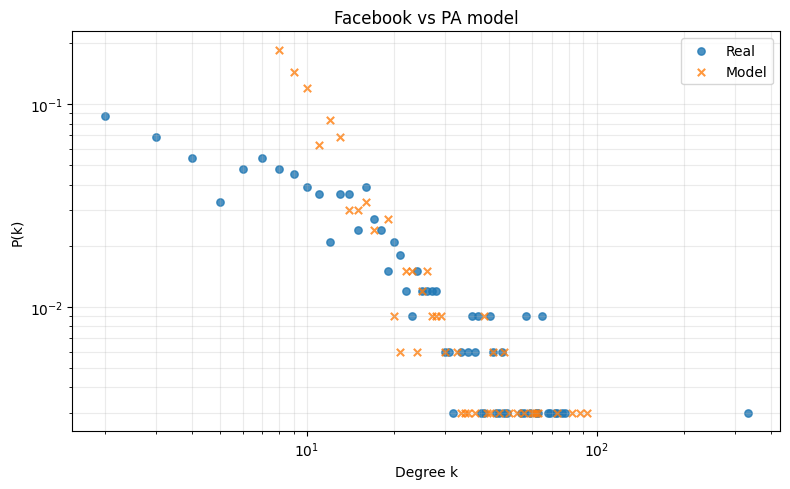

Section 2 passed! (visual check: both distributions visible on log-log)


In [11]:
# --- Validation ---
# This should produce a plot without errors
_g_ba = preferential_attachment(G_fb.number_of_nodes(), 8, seed=SEED)
compare_degree_dists(G_fb, _g_ba, title="Facebook vs PA model")
print("Section 2 passed! (visual check: both distributions visible on log-log)")

---
## Section 3: Hub Detection (10 pts)

Find all nodes whose degree exceeds `threshold_factor` times the average degree.
Return a list of those node IDs.

In [14]:
def find_hubs(G, threshold_factor=3.0):
    """Find hub nodes with degree > threshold_factor * avg_degree.

    Parameters
    ----------
    G : nx.Graph
    threshold_factor : float

    Returns
    -------
    list of nodes
    """
    avg_degree = 2 * G.number_of_edges() / G.number_of_nodes()
    threshold = threshold_factor * avg_degree
    return [node for node, degree in G.degree() if degree > threshold]

In [15]:
# --- Validation ---
_hubs = find_hubs(G_fb, threshold_factor=3.0)
assert isinstance(_hubs, list)
assert len(_hubs) > 0, "Facebook should have hubs"

_avg_deg = 2 * G_fb.number_of_edges() / G_fb.number_of_nodes()
_threshold = 3.0 * _avg_deg
for h in _hubs:
    assert G_fb.degree(h) > _threshold, (
        f"Node {h} degree {G_fb.degree(h)} below threshold {_threshold}"
    )

print(f"Found {len(_hubs)} hubs in Facebook (threshold = {_threshold:.1f})")
print(f"Hub degrees: {sorted([G_fb.degree(h) for h in _hubs], reverse=True)}")
print("Section 3 passed!")

Found 18 hubs in Facebook (threshold = 51.2)
Hub degrees: [333, 78, 76, 73, 72, 69, 68, 65, 65, 65, 63, 62, 59, 57, 57, 57, 56, 55]
Section 3 passed!


---
## Section 4: KS Degree Fit (10 pts)

Use the two-sample Kolmogorov-Smirnov test (`scipy.stats.ks_2samp`) to quantify how well
a model's degree distribution matches a real network.

Return the KS statistic (lower = better fit).

In [19]:
def ks_degree_fit(G_real, G_model):
    """Compute KS statistic between degree distributions.

    Parameters
    ----------
    G_real : nx.Graph
    G_model : nx.Graph

    Returns
    -------
    float  (KS statistic; lower = better fit)
    """
    deg_real = [d for _, d in G_real.degree()]
    deg_model = [d for _, d in G_model.degree()]
    ks_stat, _ = stats.ks_2samp(deg_real, deg_model)
    return float(ks_stat)

In [20]:
# --- Validation ---
n_fb = G_fb.number_of_nodes()
avg_deg_fb = 2 * G_fb.number_of_edges() / n_fb

_g_er = models.erdos_renyi(n_fb, avg_deg_fb)
_g_ba = preferential_attachment(n_fb, max(1, round(avg_deg_fb / 2)), seed=SEED)

_ks_er = ks_degree_fit(G_fb, _g_er)
_ks_ba = ks_degree_fit(G_fb, _g_ba)

assert isinstance(_ks_er, float)
assert 0 <= _ks_er <= 1
assert 0 <= _ks_ba <= 1

# BA should fit Facebook better than ER
assert _ks_ba < _ks_er, f"PA KS={_ks_ba:.3f} should be < ER KS={_ks_er:.3f}"
print(f"KS (ER vs Facebook): {_ks_er:.4f}")
print(f"KS (PA vs Facebook): {_ks_ba:.4f}")
print(f"PA fits better (lower KS)")
print("Section 4 passed!")

KS (ER vs Facebook): 0.4521
KS (PA vs Facebook): 0.3922
PA fits better (lower KS)
Section 4 passed!


---
## 5. CCDF & Power-Law Exponent (10 pts)

Implement two functions:

1. **`compute_ccdf(degrees)`** — given a degree sequence, return sorted arrays `(k_values, ccdf_values)` where `ccdf_values[i] = P(K ≥ k_values[i])`. Sort by k descending (largest degree first).

2. **`estimate_alpha(degrees, k_min)`** — estimate the power-law exponent using MLE:

$$\hat{\alpha} = 1 + n \left[ \sum_{i=1}^{n} \ln \frac{x_i}{x_{\min}} \right]^{-1}$$

where $x_i$ are degree values $\geq k_{\min}$ and $n$ is the count of such values.

Do NOT call `netsci.utils.fit_power_law`.

In [21]:
def compute_ccdf(degrees):
    """Compute the complementary CDF of a degree sequence.

    Parameters
    ----------
    degrees : array-like — degree values

    Returns
    -------
    (np.ndarray, np.ndarray) — (k_values, ccdf_values) sorted by k descending
    """
    deg = np.asarray(degrees)
    if deg.size == 0:
        return np.array([]), np.array([])

    k_values = np.sort(deg)[::-1]
    n = k_values.size
    ccdf_values = np.arange(1, n + 1) / n
    return k_values, ccdf_values


def estimate_alpha(degrees, k_min=1):
    """Estimate power-law exponent using MLE.

    Parameters
    ----------
    degrees : array-like — degree values
    k_min : int — minimum degree threshold

    Returns
    -------
    float — estimated exponent alpha
    """
    deg = np.asarray(degrees, dtype=float)
    tail = deg[deg >= k_min]

    if tail.size == 0:
        raise ValueError("No degree values >= k_min")

    denom = np.sum(np.log(tail / k_min))
    if denom <= 0:
        raise ValueError("Invalid data for MLE denominator")

    alpha = 1 + tail.size / denom
    return float(alpha)

In [23]:
# --- Validation ---
# Test compute_ccdf
_degs = [1, 1, 2, 2, 3, 5, 10]
_k, _p = compute_ccdf(_degs)
assert len(_k) == len(_degs)
assert _p[0] < 0.5, "CCDF at max degree should be small (e.g. ~1/n)"
assert abs(_p[-1] - 1.0) < 1e-6, "CCDF of smallest degree should be ~1.0"
# k should be sorted descending
assert all(_k[i] >= _k[i + 1] for i in range(len(_k) - 1)), (
    "k values should be sorted descending"
)

# Test estimate_alpha on BA model
_g_ba = preferential_attachment(1000, 3, seed=SEED)
_ba_degs = [d for _, d in _g_ba.degree()]
_alpha = estimate_alpha(_ba_degs, k_min=3)
assert isinstance(_alpha, float)
# BA theory predicts γ=3.0 for large N, but finite-size effects lower it
assert 1.8 < _alpha < 4.0, f"Expected α in plausible range, got {_alpha:.2f}"
print(f"BA(1000, 3) exponent: α = {_alpha:.2f}")
print(f"(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)")
print("Section 5 passed!")

BA(1000, 3) exponent: α = 3.19
(Theory predicts 3.0 for large N; finite-size effects shift the estimate.)
Section 5 passed!


---
## Section 6: Network Robustness (20 pts)

Implement two attack strategies on a network. Both functions should:
1. Make a **copy** of the graph
2. Remove the specified fraction of nodes
3. Return `(G_remaining, gcc_fraction)` where `gcc_fraction` is the size of the giant component divided by the **original** number of nodes

`random_removal(G, fraction)`: remove nodes uniformly at random. Create the RNG inside the function with `np.random.default_rng(SEED)`.

`targeted_removal(G, fraction)`: remove nodes in order of **decreasing degree**, recalculating degrees after each removal.

In [26]:
def random_removal(G, fraction):
    """Remove a random fraction of nodes and measure giant component.

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    G_remaining = G.copy()
    n0 = G.number_of_nodes()
    n_remove = int(n0 * fraction)

    rng = np.random.default_rng(SEED)
    nodes = list(G_remaining.nodes())
    to_remove = rng.choice(nodes, size=n_remove, replace=False) if n_remove > 0 else []
    G_remaining.remove_nodes_from(to_remove)

    if G_remaining.number_of_nodes() == 0:
        return G_remaining, 0.0

    gcc_size = len(max(nx.connected_components(G_remaining), key=len))
    gcc_fraction = gcc_size / n0
    return G_remaining, float(gcc_fraction)


def targeted_removal(G, fraction):
    """Remove highest-degree nodes one at a time (recalculating degrees).

    Parameters
    ----------
    G : nx.Graph
    fraction : float (0 to 1)

    Returns
    -------
    (nx.Graph, float) — (remaining graph, gcc_fraction relative to original N)
    """
    G_remaining = G.copy()
    n0 = G.number_of_nodes()
    n_remove = int(n0 * fraction)

    for _ in range(n_remove):
        if G_remaining.number_of_nodes() == 0:
            break
        node_max_deg = max(G_remaining.degree(), key=lambda x: x[1])[0]
        G_remaining.remove_node(node_max_deg)

    if G_remaining.number_of_nodes() == 0:
        return G_remaining, 0.0

    gcc_size = len(max(nx.connected_components(G_remaining), key=len))
    gcc_fraction = gcc_size / n0
    return G_remaining, float(gcc_fraction)

In [28]:
# --- Validation ---
_G_r, _gcc_r = random_removal(G_air, 0.2)
assert isinstance(_G_r, nx.Graph)
assert _G_r.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_r <= 1.0
# Original unchanged
assert G_air.number_of_nodes() == 500, "Original graph should not be modified"

_G_t, _gcc_t = targeted_removal(G_air, 0.2)
assert isinstance(_G_t, nx.Graph)
assert _G_t.number_of_nodes() == G_air.number_of_nodes() - int(
    G_air.number_of_nodes() * 0.2
)
assert 0 <= _gcc_t <= 1.0

# Targeted should reduce giant component more than random
assert _gcc_t < _gcc_r, (
    f"Targeted ({_gcc_t:.3f}) should shrink GCC more than random ({_gcc_r:.3f})"
)
print(f"Random removal (20%): GCC = {_gcc_r:.3f}")
print(f"Targeted removal (20%): GCC = {_gcc_t:.3f}")
print("Targeted attack is more devastating — the robustness paradox!")
print("Section 6 passed!")

Random removal (20%): GCC = 0.774
Targeted removal (20%): GCC = 0.010
Targeted attack is more devastating — the robustness paradox!
Section 6 passed!


---
## Written Questions (15 pts)

### Question 1 (5 pts)

Why does the BA degree distribution look different from ER on a log-log plot?
What mechanism in the BA model causes the fat tail, and why can't ER produce one?

**Hints to guide your thinking:**
- *On a log-log plot, what shape does a Poisson distribution make? What about a power law?*
- *In ER, each edge exists independently with the same probability. What does this imply about the variance of degree?*
- *In BA, a node that arrives early accumulates connections over time. Why can't this "rich get richer" dynamic happen in ER, where all edges are assigned simultaneously?*

**Your Answer:**

On a log-log plot, ER looks curved/truncated (Poisson-like), while BA is closer to a straight-line tail (power-law-like). 

The reason is mechanism: BA grows over time and uses preferential attachment(“rich get richer”), so early/high-degree nodes attract even more links and become hubs, creating a fat tail. ER does not have this feedback: each edge is added independently with the same probability, so degrees concentrate around the mean (lower relative variance) and extreme hubs are rare.

### Question 2 (5 pts)

In the lab, we saw that BA networks are "ultra-small" — their average path length grows as
$\ln N / \ln \ln N$, slower than ER's $\ln N$.

(a) Explain *why* hubs create this shortcut effect. (Think about what happens when you try to
route between two random nodes — how many hops to reach a hub, and how many hops between hubs?)

(b) We also saw that Facebook's degree distribution is better fit by an exponential than a power
law, despite having clear hubs. Does a network need to be "truly scale-free" (strict power-law
degree distribution) to benefit from the ultra-small property, or is having *some* high-degree
hubs sufficient? Justify your reasoning.

**Hints to guide your thinking:**
- *In a scale-free network, most nodes are within 1-2 hops of a hub. Why?*
- *The ultra-small property depends on the existence of high-degree nodes, not on the exact shape of the degree distribution. Think about what ⟨k²⟩ measures.*
- *Broido & Clauset (2019) found that few networks are "strictly" scale-free. Does this mean the BA model is useless?*

**Your Answer:**

a) Hubs shrink paths because routing between two random nodes often looks like: node A -> nearby hub -> (possibly another hub) -> node B. Most nodes are only a few hops from a high-degree hub, and hubs are well-connected to each other, so long routes collapse into a small number of steps.

b) A network does not need to be strictly power-law to get ultra-small behavior. What matters is the presence of sufficiently high-degree nodes (large degree heterogeneity, high k^2 ), which creates shortcut structure. So even if Facebook is better fit by an exponential tail than a perfect power law, clear hubs can still produce very short path lengths. This is why BA remains useful: it captures the hub mechanism, even if real networks are not perfectly scale-free.

### Question 3 (5 pts)

Why does targeted hub removal push the Molloy-Reed ratio (⟨k²⟩/⟨k⟩) below 2 faster than
random removal?

**Use your results from Section 6** to support your answer. Quote the GCC fractions for
random vs targeted removal at 20% and explain the asymmetry in terms of ⟨k²⟩.

**Hints to guide your thinking:**
- *The Molloy-Reed ratio depends heavily on ⟨k²⟩ — the average squared degree. Which nodes contribute most to this quantity?*
- *In a scale-free network, hubs have degree much larger than average. How does removing a node with degree 100 vs degree 5 affect ⟨k²⟩?*
- *Random removal mostly hits low-degree nodes (because there are many more of them). How much does removing a degree-5 node change ⟨k²⟩?*

**Your Answer:**

Targeted removal collapses the network faster because hubs dominate k^2 (degree is squared), so removing a high-degree node causes a huge drop in the Molloy-Reed ratio k^2 / k. Random removal mostly deletes low-degree nodes, which changes k^2 much less.

Your Section 6 results show this clearly at 20% removal:
- Random: GCC =0.774
- Targeted: GCC =0.010

So targeted attack pushes the system below the percolation threshold much sooner, while random failures leave most of the giant component intact.